In [1]:
import scanpy as sc
import harmonypy as hm

In [14]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/SmoNull_Brain_system.h5ad")


In [15]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_variable_pearson', 'highly_variable_nbatches_pearson', 'highly_variable_intersection_pearson', 'highly_variable_rank(pearson)'
    uns: 'Celltype_colors', 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'X_umap_pearson', 'hvg_log1p', 'hvg_pearson', 'neighbors_log1p', 'neighbors_pearson', 'pca'
    obsm: 'X_pca_harmony_log1p', 'X_pca_ha

# Integration with Scran Normalization
Quick note on scran normalization - Scran uses some R function to calculate the size_factor, which was used in place of the default size factor in log1p. 
In other word, the denominator is not the same

## Finding Highly Variable Genes 

In [16]:
# Use scran normalization
adata.X = adata.layers["scran_normalization"]

In [17]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="Library.ident")

In [18]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_variable_pearson', 'highly_variable_nbatches_pearson', 'highly_variable_intersection_pearson', 'highly_variable_rank(pearson)', 'highly_variable', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Celltype_colors', 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'X_umap_pearson', 'h

In [19]:
# Renaming to scran
adata.var["highly_variable_scran"] = adata.var["highly_variable"]
del adata.var["highly_variable"]
adata.var["highly_variable_nbatches_scran"] = adata.var["highly_variable_nbatches"]
del adata.var["highly_variable_nbatches"]
adata.var["highly_variable_intersection_scran"] = adata.var["highly_variable_intersection"]
del adata.var["highly_variable_intersection"]
adata.uns["hvg_scran"] = adata.uns["hvg"]
del adata.uns["hvg"]

### Finding PCA


In [24]:
sc.pp.scale(adata)
sc.pp.pca(adata, mask_var="highly_variable_scran")

/home/yubin/.conda/envs/scRNAseq_python/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


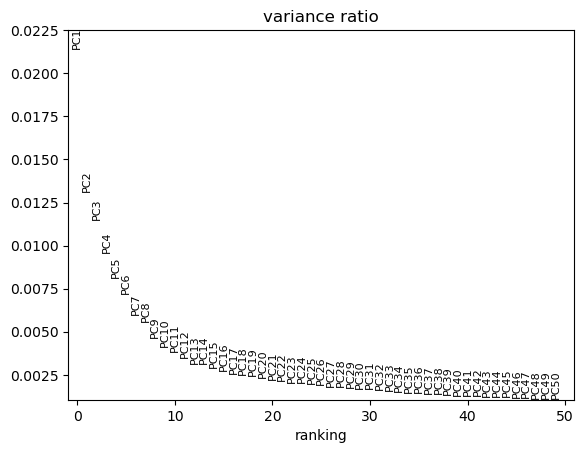

In [25]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=False)

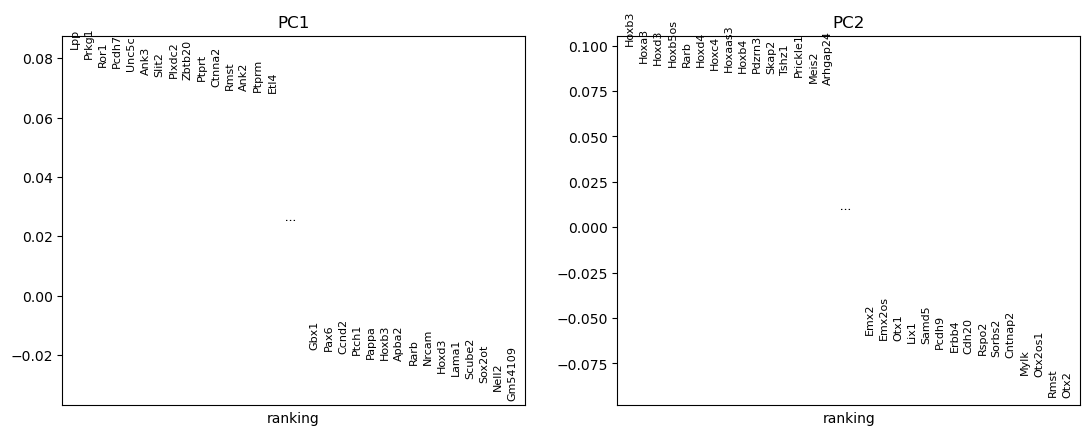

In [26]:
sc.pl.pca_loadings(adata, components = [1,2], show = True)

In [29]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_variable_pearson', 'highly_variable_nbatches_pearson', 'highly_variable_intersection_pearson', 'highly_variable_rank(pearson)', 'dispersions', 'dispersions_norm', 'highly_variable_scran', 'highly_variable_nbatches_scran', 'highly_variable_intersection_scran'
    uns: 'Celltype_colors', 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'X

In [28]:
# Again taking only a subset of pc for downstream processing
adata.obsm["X_pca_scran"] = adata.obsm["X_pca"][:, :13]
del adata.obsm["X_pca"]

### Harmony Integration

In [30]:
sc.external.pp.harmony_integrate(adata, key="Library.ident", max_iter_harmony=20, basis = "X_pca_scran", adjusted_basis="X_pca_harmony_scran")

2026-03-10 17:59:47,217 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-03-10 17:59:50,023 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-10 17:59:50,145 - harmonypy - INFO - Iteration 1 of 20
2026-03-10 17:59:57,182 - harmonypy - INFO - Iteration 2 of 20
2026-03-10 18:00:04,227 - harmonypy - INFO - Iteration 3 of 20
2026-03-10 18:00:10,973 - harmonypy - INFO - Converged after 3 iterations


In [31]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_variable_pearson', 'highly_variable_nbatches_pearson', 'highly_variable_intersection_pearson', 'highly_variable_rank(pearson)', 'dispersions', 'dispersions_norm', 'highly_variable_scran', 'highly_variable_nbatches_scran', 'highly_variable_intersection_scran'
    uns: 'Celltype_colors', 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'X

### Calculating Neightbor + Umap

In [32]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony_scran", key_added="neighbors_scran")

/home/yubin/.conda/envs/scRNAseq_python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
sc.tl.umap(adata, neighbors_key="neighbors_scran", key_added="X_umap_scran")

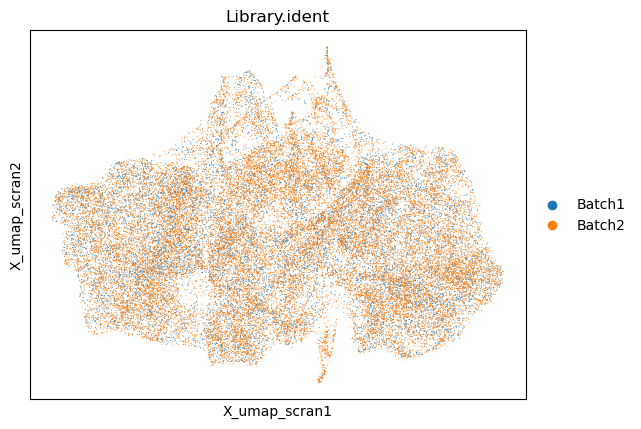

In [34]:
sc.pl.embedding(adata, basis = "X_umap_scran", color = "Library.ident", size = 2)

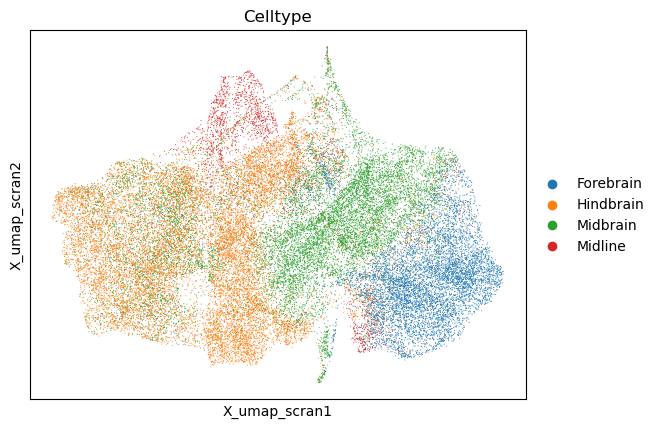

In [35]:
sc.pl.embedding(adata, basis = "X_umap_scran", color = "Celltype", size = 2)

In [36]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_variable_pearson', 'highly_variable_nbatches_pearson', 'highly_variable_intersection_pearson', 'highly_variable_rank(pearson)', 'dispersions', 'dispersions_norm', 'highly_variable_scran', 'highly_variable_nbatches_scran', 'highly_variable_intersection_scran'
    uns: 'Celltype_colors', 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'X

In [37]:
adata.write_h5ad("/project/imoskowitz/yubin/1-sc_practice/SmoNull_Brain_system.h5ad")